# ACCESS-OM3 MCW 100km ERA IAF Scaling

End-to-end pipeline generating scaling plots for [ACCESS-OM3 MCW 100km ERA IAF configuration](https://github.com/ACCESS-NRI/access-om3-configs/tree/dev-MCW_100km_era_iaf).

In [1]:
%load_ext autoreload
%autoreload 2

## Package versions

In [2]:
from importlib.metadata import version
for pkg in ("access.config.utils", "access.profiling",):
    print(f"{pkg}: {version(pkg)}")

access.config.utils: 0.5.dev2+gbfb577860
access.profiling: 0.2.dev30+gcadb7841e


## Setup
The following variables control where the configurations and model run outputs are saved.

In [3]:
## Imports
from pathlib import Path

from access.config.parallel_domain import Domain
from access.profiling.access_models import OM3Profiling, OM3Configuration

test_path = f"/scratch/tm70/model_scaling/ACCESS-OM3/dev-MCW_100km_era_iaf"
archive_path = f"/g/data/tm70/model_scaling/ACCESS-OM3/dev-MCW_100km_era_iaf/archive"

GLOBAL_GRID = Domain(shape=(360, 324))
OM3_MCW_100KM = OM3Configuration(
    name="MCW-100km",
    ocean=GLOBAL_GRID,
    sea_ice=GLOBAL_GRID,
    atmosphere=GLOBAL_GRID,
    runoff=GLOBAL_GRID,
    waves=GLOBAL_GRID,
)

om3_profiling = OM3Profiling(work_dir=Path(test_path), archive_dir=Path(archive_path), configuration=OM3_MCW_100KM)
om3_profiling.set_control(repository="https://github.com/ACCESS-NRI/access-om3-configs.git", commit="dev-MCW_100km_era_iaf")

## Generate experiments

We will perform a simple scaling study, varying the total number of nodes used over `[1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 8.0]`. We will search for different layouts that closely match a scaled 2-node 100km MCW ERA IAF config.

In [4]:
from access.config.parallel_allocation_strategies import RootAllocation, FreeAllocation, WholeRangeAllocation
from access.config.parallel_constraints import SubdomainAspectRatioConstraint, RankRatioGroupConstraint, MaxWastedCoreFractionConstraint

# Define how the cores should be allocated to the components
allocation_strategy = RootAllocation(
    subcomponents={
        "ocn": FreeAllocation(min_core_fraction=0.45, core_step=20),
        "wav": FreeAllocation(min_core_fraction=0.4, core_step=15),
        "shared": FreeAllocation(min_core_fraction=0.05, core_step=2,
            subcomponents={
                "ice": WholeRangeAllocation(local_constraints=(SubdomainAspectRatioConstraint(max_ratio=1.5),),),
                "cpl": WholeRangeAllocation(),
                "rof": WholeRangeAllocation(),
                "atm": WholeRangeAllocation(),
            },
        ),
    },
    local_constraints=(MaxWastedCoreFractionConstraint(max_fraction=0.01),),
       group_constraints=(
       RankRatioGroupConstraint(name_a="ocn", name_b="wav", min_ratio=1.1),
    #    RankRatioGroupConstraint(name_a="shared", name_b="ocn", min_ratio=1),
   ),
)


from access.config.parallel_layouts import iter_layouts

for num_nodes in [1, 2, 3, 4, 5, 6, 8]:
    layouts = list(iter_layouts(OM3_MCW_100KM.parallel_component, num_nodes*104, allocations=allocation_strategy))
    print(f"Num nodes: {num_nodes}, Num layouts: {len(layouts)}")

# layouts = list(iter_layouts(OM3_MCW_100KM.parallel_component, 8*104, allocations=allocation_strategy))
# print(len(layouts))
# for layout in layouts:
#    print(layout.sub_layouts[0])
#    print(layout.sub_layouts[1])
#    print(layout.sub_layouts[2])
#    print("\n")



Num nodes: 1, Num layouts: 0
Num nodes: 2, Num layouts: 1
Num nodes: 3, Num layouts: 1
Num nodes: 4, Num layouts: 1
Num nodes: 5, Num layouts: 7
Num nodes: 6, Num layouts: 6
Num nodes: 8, Num layouts: 14


In [ ]:
from ruamel.yaml.scalarstring import (
        DoubleQuotedScalarString as dq,
    )

###### Generate the configuration and write to file
num_nodes_list = [1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 8.0]
control_options = {
            "config.yaml": {
                "manifest": {"reproduce": {"exe": False}},
                "postscript": "REMOVE",
                "mem": "REMOVE",
                "env":
                    {"ESMF_RUNTIME_PROFILE" : dq("on"), "ESMF_RUNTIME_PROFILE_OUTPUT" : dq("SUMMARY")},
            }
}

def walltime(num_nodes):
    return 36 * 2.0/num_nodes # use a 12 hrs time for 2-node runs, and then scale linearly

om3_profiling.generate_scaling_experiments(num_nodes_list=num_nodes_list, control_options=control_options, cores_per_node=104, walltime=walltime, allocations=allocation_strategy)

No layouts found for 1.0 nodes (104 cores). Check the bounds and the constraints of the allocation strategy.


-- Test directory /scratch/tm70/model_scaling/ACCESS-OM3/dev-MCW_100km_era_iaf already exists!
-- Test dir: /scratch/tm70/model_scaling/ACCESS-OM3/dev-MCW_100km_era_iaf/config already exists, hence not cloning https://github.com/ACCESS-NRI/access-om3-configs.git
Checked out branch: ctrl
laboratory path:  /scratch/tm70/ms2335/access-om3
binary path:  /scratch/tm70/ms2335/access-om3/bin
input path:  /scratch/tm70/ms2335/access-om3/input
work path:  /scratch/tm70/ms2335/access-om3/work
archive path:  /scratch/tm70/ms2335/access-om3/archive
Metadata and UUID generation is disabled. Experiment name used for archival: config
No prior restart path provided. Skip adding parent branch time to metadata.
Removed archive symlink to /scratch/tm70/ms2335/access-om3/archive/om3-layout_MCW-100km_atm_64_cpl_64_ice_8x8_ocn_400_rof_64_wav_360
-- Branch om3-layout_MCW-100km_atm_16_cpl_16_ice_4x4_ocn_100_rof_16_wav_90 already exists, switching to it only!
Checked out branch: om3-layout_MCW-100km_atm_16_cpl

## Run experiments

Next we run the experiments

In [6]:
om3_profiling.run_experiments()

## Parsing and plotting experiment results

In [7]:
from access.profiling.metrics import tmax

# Parse the data
om3_profiling.parse_profiling_data()

# Get the best (fastest) layouts for each node count
best_experiments = om3_profiling.select_best_experiments(component="payu",region="payu_model_run_duration_seconds", metric=tmax)
best_experiments

['om3-layout_MCW-100km_atm_16_cpl_16_ice_4x4_ocn_100_rof_16_wav_90',
 'om3-layout_MCW-100km_atm_16_cpl_16_ice_4x4_ocn_160_rof_16_wav_135',
 'om3-layout_MCW-100km_atm_36_cpl_36_ice_6x6_ocn_200_rof_36_wav_180',
 'om3-layout_MCW-100km_atm_70_cpl_70_ice_10x7_ocn_240_rof_70_wav_210',
 'om3-layout_MCW-100km_atm_54_cpl_54_ice_9x6_ocn_300_rof_54_wav_270',
 'om3-layout_MCW-100km_atm_104_cpl_104_ice_13x8_ocn_380_rof_104_wav_345']

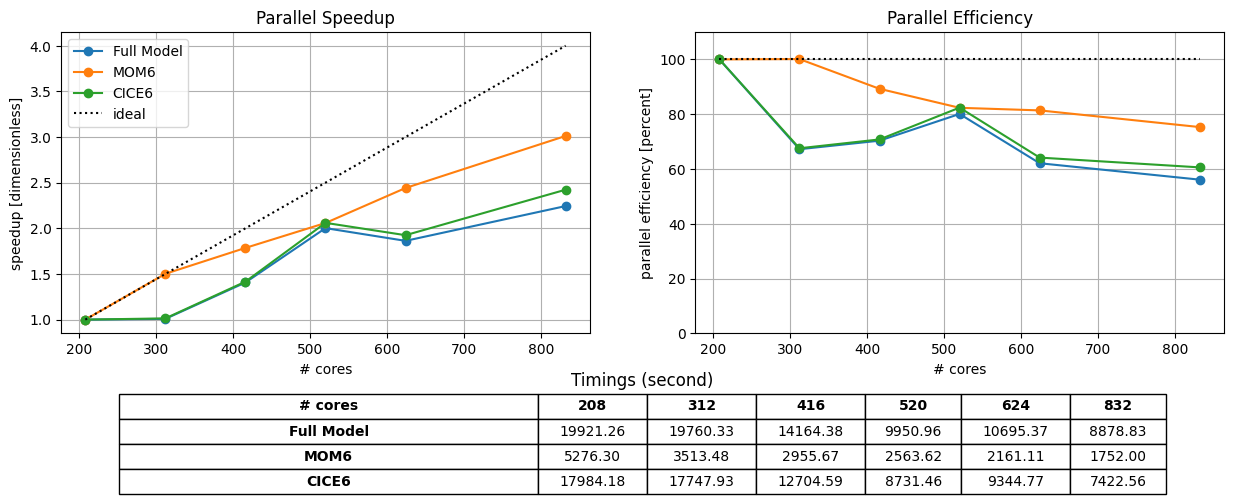

In [8]:
# Plot the scaling data, using only the best experiments
fig = om3_profiling.plot_scaling_data(
    components=["payu", "MOM6", "CICE6"],
    regions=[
        ["payu_model_run_duration_seconds"],
        ["Ocean"],
        ["Total"],
    ],
    metric=tmax,
    region_relabel_map={
        "payu_model_run_duration_seconds": "Full Model",
        "Ocean": "MOM6",
        "Total": "CICE6",
    },
    experiments=best_experiments,
    xlabel="# cores",
)

## Summary

We have presented the strong scaling results for the [100km MCW ERA IAF configuration](https://github.com/ACCESS-NRI/access-om3-configs/tree/dev-MCW_100km_era_iaf) of ACCESS-OM3. The underlying components are MOM6 for ocean, CICE6 for the ice model, WW3 for the wave model, using the NUOPC coupler from ESMF. The atmosphere and runoff are applied as forcings. There are three concurrent tasks - i) MOM6, ii) WW3 and iii) a shared concurrent task consisting of atmosphere, coupler, runoff, and CICE running sequentially within the shared cores. The released configuration for ACCESS-OM3 100km MCW IAF configuration uses 2-nodes on the `normalsr` queue with `sapphirerapids` cpus, where each node contains 104 cores. The table shows the raw data from the runs corresponding to each of the components, and the overall model runtime. The columns represent 2, 3, 4, 5, 6, and 8 node configs.

We have varied the number of nodes between 2 and 8, and for each case, we have tested several options with different partitioning of the total number of available cores between the two components. In the plots above, we have presented the best performing configuration for each case. <FILL IN>

CICE dominates the scaling results and it is to be expected that any code will plateau when the serial part (potentially from synchronisation) starts to dominate (Amdahl's law). In addition, due to the concurrent running of the two components, we expect that this drop-off is partially from imperfect loadbalancing, and further investigation is required to improve the scaling for running ACCESS-OM3 >= 8 nodes. 

# Archive

Archive experiments.

In [9]:
om3_profiling.archive_experiments()